# Meta-Atom Library Optimization — Focusing with Interpolated Unit Cells

Notebook version of `scripts/metaatom_optimization_example.py`.  This example is closely
related to `examples/lens_optimization_example.ipynb`: we still optimize a device to focus
a plane wave at a target pixel after propagation.

The key difference is that the trainable surface is **not** an unconstrained phase mask.
Instead, each pixel is parameterized by a **meta-atom geometry** (here a square-pillar side
length), and the complex transmission is obtained from a precomputed library using
`MetaAtomInterpolationLayer`.

### Outline

1. **Imports** for JAX/Optax and meta-atom optics layers.
2. **Paths** to the LUT sweep file and output artifacts.
3. **Library utilities** for loading the meta-atom sweep and building the module.
4. **Experiment settings** (wavelength selection, grid, propagation, bounds).
5. **Optimization objective** and parameter initialization.
6. **Training loop** for the raw geometry parameters.
7. **Evaluation** vs a hyperbolic-phase reference lens.
8. **Saved summary and diagnostic figures**.


## 1  Imports

As in the lens optimization notebook, we use JAX for differentiation and Optax for
optimization.  The new pieces are:

- `MetaAtomLibrary` for the tabulated unit-cell response, and
- `MetaAtomInterpolationLayer` for converting trainable geometry parameters into a complex
  transmission map at the chosen wavelength.


In [17]:
from __future__ import annotations

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax

from fouriax.optics import (
    Field,
    Grid,
    MetaAtomInterpolationLayer,
    MetaAtomLibrary,
    OpticalLayer,
    OpticalModule,
    PhaseMask,
    Spectrum,
    plan_propagation,
)

%matplotlib inline

## 2  Repository Root and Data Paths

This notebook resolves the repository root dynamically and loads a precomputed square-pillar
parameter sweep (`.npz`) from `data/meta_atoms/`.  Outputs are written to the shared
`artifacts/` directory.

The notebook fails early if the sweep file is missing, since all subsequent steps depend on
that lookup table.


In [18]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing scripts/ and src/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NPZ_PATH = REPO_ROOT / "data" / "meta_atoms" / "square_pillar_0p7um_cell_sweep_results.npz"
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
SUMMARY_PATH = ARTIFACTS_DIR / "metaatom_opt_summary.json"
PLOT_PATH = ARTIFACTS_DIR / "metaatom_opt_overview.png"

print(f"REPO_ROOT={REPO_ROOT}")
print(f"NPZ_PATH={NPZ_PATH}")
if not NPZ_PATH.exists():
    raise FileNotFoundError(f"missing sweep file: {NPZ_PATH}")


REPO_ROOT=/Users/liam/fouriax
NPZ_PATH=/Users/liam/fouriax/data/meta_atoms/square_pillar_0p7um_cell_sweep_results.npz


## 3  Library Utilities

### Loading the meta-atom lookup table

The sweep file stores transmission magnitude and phase over a grid of:

- optical frequencies (or wavelengths), and
- geometric parameters (square-pillar side length).

The helper converts these tabulated values into a complex transmission response

$$
t(g, \lambda) = a(g, \lambda)\,e^{i\phi(g, \lambda)},
$$

and packages the result into a `MetaAtomLibrary` object.

### Building the optical module

`build_module(...)` assembles an `OpticalModule` with two layers:

1. `MetaAtomInterpolationLayer` (learned transmissive surface), and
2. free-space propagation to the target plane.

This mirrors the lens notebook's phase-mask-plus-propagation pipeline, but replaces the
phase mask with a **library-constrained** transmissive element.


In [19]:
SPEED_OF_LIGHT_M_PER_S = 299_792_458.0


def load_square_pillar_library(npz_path: Path) -> MetaAtomLibrary:
    """Load LUT from NPZ keys: freqs [Hz], side_lengths [m], trans, phase."""
    with np.load(npz_path) as data:
        freqs_hz = np.asarray(data["freqs"], dtype=np.float64).reshape(-1)
        side_lengths_m = np.asarray(data["side_lengths"], dtype=np.float64).reshape(-1)
        trans = np.asarray(data["trans"], dtype=np.float64)
        phase = np.asarray(data["phase"], dtype=np.float64)

    wavelengths_um = (SPEED_OF_LIGHT_M_PER_S / freqs_hz) * 1e6
    side_lengths_um = side_lengths_m * 1e6

    wav_order = np.argsort(wavelengths_um)
    side_order = np.argsort(side_lengths_um)

    wavelengths_um = wavelengths_um[wav_order]
    side_lengths_um = side_lengths_um[side_order]

    trans = trans[side_order, :][:, wav_order]
    phase = phase[side_order, :][:, wav_order]

    transmission_complex = trans.T * np.exp(1j * phase.T)

    return MetaAtomLibrary.from_complex(
        wavelengths_um=jnp.asarray(wavelengths_um, dtype=jnp.float32),
        parameter_axes=(jnp.asarray(side_lengths_um, dtype=jnp.float32),),
        transmission_complex=jnp.asarray(transmission_complex),
    )


def build_module(
    library: MetaAtomLibrary,
    raw_params: jnp.ndarray,
    min_bounds: jnp.ndarray,
    max_bounds: jnp.ndarray,
    propagator: OpticalLayer,
) -> OpticalModule:
    return OpticalModule(
        layers=(
            MetaAtomInterpolationLayer(
                library=library,
                raw_geometry_params=raw_params,
                min_geometry_params=min_bounds,
                max_geometry_params=max_bounds,
            ),
            propagator,
        )
    )


## 4  Fixed Experiment Settings

As in `examples/lens_optimization_example.ipynb`, we choose a grid, a propagation distance,
and a center pixel target.  The main extra step here is selecting a wavelength from the
meta-atom library (nearest available sample to `selected_wavelength_um`).

We also extract the valid geometry interval from the library axis and define
`min_bounds`/`max_bounds`, which constrain the interpolated meta-atom parameters during
optimization.


In [20]:
library = load_square_pillar_library(NPZ_PATH)

selected_wavelength_um = 1.30
nearest_idx = int(jnp.argmin(jnp.abs(library.wavelengths_um - selected_wavelength_um)))
wavelength_um = float(library.wavelengths_um[nearest_idx])
frequency_hz = SPEED_OF_LIGHT_M_PER_S / (wavelength_um * 1e-6)

grid = Grid.from_extent(nx=64, ny=64, dx_um=0.7, dy_um=0.7)
spectrum = Spectrum.from_scalar(wavelength_um)
field_in = Field.plane_wave(grid=grid, spectrum=spectrum)

distance_um = 100.0
target_xy = (grid.nx // 2, grid.ny // 2)

propagator = plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=distance_um,
)

side_axis = library.parameter_axes[0]
min_bounds = jnp.array([side_axis[0]], dtype=jnp.float32)
max_bounds = jnp.array([side_axis[-1]], dtype=jnp.float32)


## 5  Optimization Objective and Initialization

### Bounded geometry parameterization

The trainable tensor `raw_params` is unconstrained, but the meta-atom layer maps it into the
library's valid geometry range.  Conceptually, each pixel parameter is bounded as

$$
g(x,y) \in [g_{\min}, g_{\max}],
$$

via a smooth transform (implemented inside `MetaAtomInterpolationLayer`).  The layer then
interpolates the complex transmission $t(g,\lambda)$ from the LUT at the selected
wavelength.

### Focusing objective (same idea as lens optimization)

Like the lens notebook, we maximize on-axis focusing at `target_xy`.  The propagated
intensity is

$$
I(x,y) = |E_{\mathrm{out}}(x,y)|^2,
$$

and this notebook uses the scalar objective

$$
\mathcal{L} = -I(x_0, y_0),
$$

where $(x_0, y_0)$ is the target pixel.  Minimizing $\mathcal{L}$ is therefore equivalent
to maximizing center intensity.

We initialize `raw_params` with small random values and set up Adam for optimization.


In [21]:
def loss_fn(raw_params: jnp.ndarray) -> jnp.ndarray:
    module = build_module(
        library=library,
        raw_params=raw_params,
        min_bounds=min_bounds,
        max_bounds=max_bounds,
        propagator=propagator,
    )
    intensity = module.forward(field_in).intensity()
    center = intensity[0, target_xy[1], target_xy[0]]
    return -center

key = jax.random.PRNGKey(0)
raw_params = 0.1 * jax.random.normal(key, (grid.ny, grid.nx), dtype=jnp.float32)

optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(raw_params)
value_and_grad = jax.value_and_grad(loss_fn)

steps = 180


## 6  Run Optimization

We iterate Adam updates on the raw geometry-parameter map.  The loss history should trend
more negative as the center intensity increases.

Periodic console prints provide a quick convergence check during interactive runs.


In [22]:
history: list[float] = []
for step in range(steps):
    loss, grads = value_and_grad(raw_params)
    updates, opt_state = optimizer.update(grads, opt_state, raw_params)
    raw_params = optax.apply_updates(raw_params, updates)
    history.append(float(loss))
    if step % 30 == 0 or step == steps - 1:
        print(f"step={step:03d} loss={float(loss):.6f}")


step=000 loss=-0.516717
step=030 loss=-75.365952
step=060 loss=-83.396507
step=090 loss=-85.912880
step=120 loss=-87.110268
step=150 loss=-86.954109
step=179 loss=-87.771843


## 7  Evaluate Optimized Device and Hyperbolic-Phase Reference

After optimization, we evaluate the final meta-atom device and compare it to the same
hyperbolic-phase focusing reference used in the lens notebook:

$$
\phi_{\mathrm{ref}}(x,y) = -k\left(\sqrt{x^2+y^2+f^2}-f\right),
\qquad k = \frac{2\pi}{\lambda}.
$$

This reference is not subject to the meta-atom library constraints, so it serves as an
idealized baseline for profile comparison.

We also inspect the learned bounded geometry map (`optimized_side_map`) and query the
library to report the local complex transmission at the center pixel.


In [23]:
final_module = build_module(
    library=library,
    raw_params=raw_params,
    min_bounds=min_bounds,
    max_bounds=max_bounds,
    propagator=propagator,
)

final_intensity = np.asarray(final_module.forward(field_in).intensity())
final_center_intensity = float(final_intensity[0, target_xy[1], target_xy[0]])
optimized_profile = final_intensity[0, target_xy[1], :]

x_um, y_um = grid.spatial_grid()
wavelength_um = float(spectrum.wavelengths_um[0])
k = 2.0 * jnp.pi / wavelength_um
hyperbolic_phase = -k * (
    jnp.sqrt(x_um * x_um + y_um * y_um + distance_um**2) - distance_um
)
reference_module = OpticalModule(
    layers=(
        PhaseMask(phase_map_rad=hyperbolic_phase[None, :, :]),
        propagator,
    )
)

reference_intensity = np.asarray(reference_module.forward(field_in).intensity())
reference_center_intensity = float(reference_intensity[0, target_xy[1], target_xy[0]])
reference_profile = reference_intensity[0, target_xy[1], :]

final_layer = MetaAtomInterpolationLayer(
    library=library,
    raw_geometry_params=raw_params,
    min_geometry_params=min_bounds,
    max_geometry_params=max_bounds,
)
optimized_side_map = np.asarray(final_layer.bounded_geometry_params()[0])
optimized_transmission = complex(
    np.asarray(
        library.interpolate_complex(
            final_layer.bounded_geometry_params()[:, target_xy[1], target_xy[0]][None, :],
            spectrum.wavelengths_um,
        )
    )[0, 0]
)


## 8  Save Summary and Figures

The final section writes `metaatom_opt_summary.json` and generates an overview figure with:

- optimization loss history,
- optimized side-length map,
- 2D focal intensity, and
- center-row intensity profile vs the hyperbolic reference.

These outputs make it easy to compare this **library-constrained** design workflow against
the unconstrained phase-mask lens optimization notebook.


saved: /Users/liam/fouriax/artifacts/metaatom_opt_summary.json
saved: /Users/liam/fouriax/artifacts/metaatom_opt_overview.png


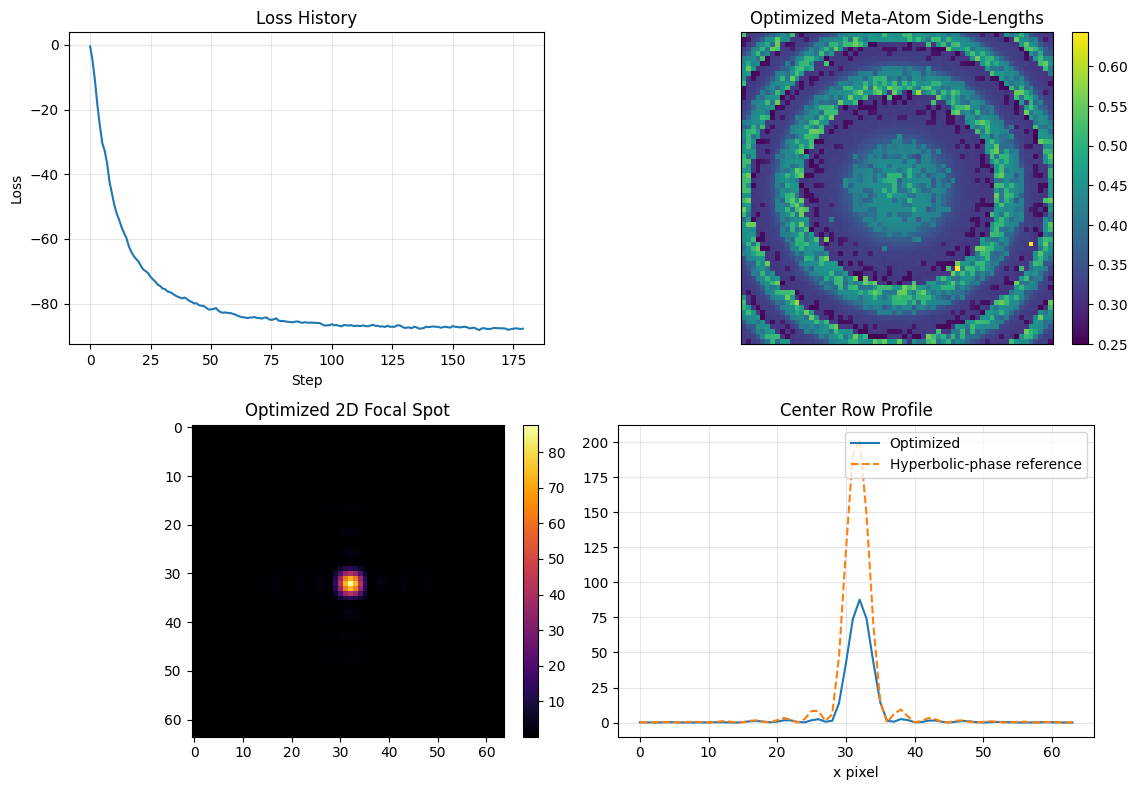

In [24]:
summary = {
    "sweep_file": str(NPZ_PATH.relative_to(REPO_ROOT)),
    "steps": steps,
    "learning_rate": 0.10,
    "selected_wavelength_um": wavelength_um,
    "selected_frequency_hz": frequency_hz,
    "side_length_range_um": [float(min_bounds[0]), float(max_bounds[0])],
    "optimized_side_length_um_mean": float(np.mean(optimized_side_map)),
    "optimized_side_length_um_min": float(np.min(optimized_side_map)),
    "optimized_side_length_um_max": float(np.max(optimized_side_map)),
    "initial_loss": history[0],
    "final_loss": history[-1],
    "optimized_transmission_abs": float(abs(optimized_transmission)),
    "optimized_transmission_phase_rad": float(np.angle(optimized_transmission)),
    "final_center_intensity": final_center_intensity,
    "reference_center_intensity": reference_center_intensity,
    "distance_um": distance_um,
}

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"saved: {SUMMARY_PATH}")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))

axes[0, 0].plot(history)
axes[0, 0].set_title("Loss History")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)

side_im = axes[0, 1].imshow(optimized_side_map, cmap="viridis")
axes[0, 1].set_title("Optimized Meta-Atom Side-Lengths")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])
plt.colorbar(side_im, ax=axes[0, 1], fraction=0.046, pad=0.04)

focus_im = axes[1, 0].imshow(final_intensity[0], cmap="inferno")
axes[1, 0].set_title("Optimized 2D Focal Spot")
plt.colorbar(focus_im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].plot(optimized_profile, label="Optimized")
axes[1, 1].plot(reference_profile, label="Hyperbolic-phase reference", linestyle="--")
axes[1, 1].set_title("Center Row Profile")
axes[1, 1].set_xlabel("x pixel")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=160)
print(f"saved: {PLOT_PATH}")
plt.show()
